In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml

In [2]:
def cfm_2_m3h(cfm):
    m3h = np.asarray(cfm) * 1.69901
    return m3h


In [3]:
test = "Test_1"
with open('./results/{}/fan_test_result.yaml'.format(test), 'r') as f:
    result_dict = yaml.safe_load(f)

device = result_dict[test]['device_name']
if 'VAV' in device:
    device = 'VAV box'
elif 'diffuser' in device:
    device = 'overhead diffuser'
    
point = result_dict[test]['point_name']
speed_spt_new = np.mean(result_dict[test]['step_2'].get('fan_speed_command'))
speed_spt_old = speed_spt_new - 10

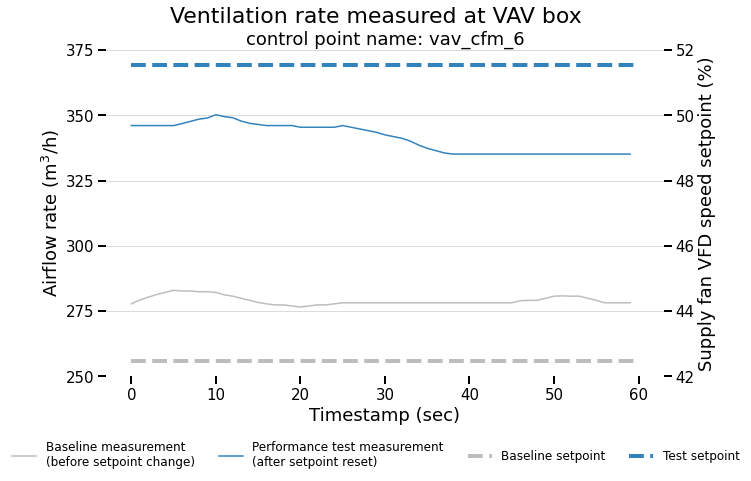

In [4]:
fig, ax1 = plt.subplots(figsize = [10, 6])
ax1.plot(cfm_2_m3h(result_dict[test]['step_1']['airflow_rate_value']), color = '#bdbdbd', label = "Baseline measurement\n(before setpoint change)")
ax1.plot(cfm_2_m3h(result_dict[test]['step_3']['airflow_rate_value']), color = '#3182bd', label = "Performance test measurement\n(after setpoint reset)")
new_ticks = np.arange(250, 380, 25)
ax1.set_ylim(new_ticks[0], new_ticks[1])
ax1.set_yticks(new_ticks)

ax2 = ax1.twinx()
ax2.hlines(y = speed_spt_old, xmin = 0, xmax = 60, color = '#bdbdbd', linestyle='--', linewidth = 4, label = "Baseline setpoint")
ax2.hlines(y = speed_spt_new, xmin = 0, xmax = 60, color = '#3182bd', linestyle='--', linewidth = 4, label = "Test setpoint")
ax2.set_yticks(np.linspace(ax2.get_ylim()[0], ax2.get_ylim()[-1], len(ax1.get_yticks())))
ax2.set_yticklabels([f"{round(tick)}" for tick in ax2.get_yticks()])
ax2.set_ylabel('Supply fan VFD speed setpoint (%)', fontsize = 18)

fig.suptitle("Ventilation rate measured at {}".format(device), fontsize = 22)
ax1.set_title("control point name: {}".format(point), fontsize = 18)
ax1.set_xlabel('Timestamp (sec)', fontsize = 18)
ax1.set_ylabel('Airflow rate (m$^3$/h)', fontsize = 18)
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0), ncol=4, frameon = False, fontsize = 12)

ax1.tick_params(axis='both', which = 'major', length=8, width=2, labelsize=15)
ax2.tick_params(axis='both', which = 'major', length=8, width=2, labelsize=15)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.yaxis.grid(True, linestyle='-', color='lightgrey')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)

fig.savefig('./results/{}.svg'.format(device))

In [5]:
test = "Test_2"
with open('./results/{}/fan_test_result.yaml'.format(test), 'r') as f:
    result_dict = yaml.safe_load(f)

device = result_dict[test]['device_name']

device = result_dict[test]['device_name']
if 'VAV' in device:
    device = 'VAV box'
elif 'diffuser' in device:
    device = 'overhead diffuser'
    
point = result_dict[test]['point_name']
speed_spt_new = np.mean(result_dict[test]['step_2'].get('fan_speed_command'))
speed_spt_old = speed_spt_new - 10

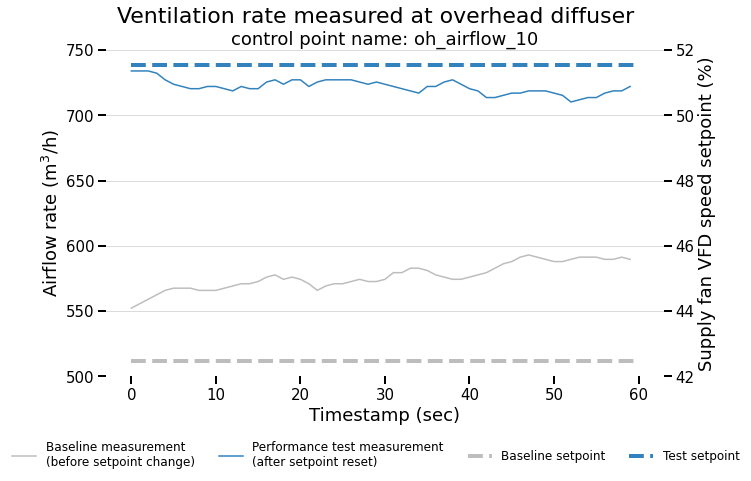

In [6]:
fig, ax1 = plt.subplots(figsize = [10, 6])
ax1.plot(cfm_2_m3h(result_dict[test]['step_1']['airflow_rate_value']), color = '#bdbdbd', label = "Baseline measurement\n(before setpoint change)")
ax1.plot(cfm_2_m3h(result_dict[test]['step_3']['airflow_rate_value']), color = '#3182bd', label = "Performance test measurement\n(after setpoint reset)")
new_ticks = np.arange(500, 760, 50)
ax1.set_ylim(new_ticks[0], new_ticks[1])
ax1.set_yticks(new_ticks)

ax2 = ax1.twinx()
ax2.hlines(y = speed_spt_old, xmin = 0, xmax = 60, color = '#bdbdbd', linestyle='--', linewidth = 4, label = "Baseline setpoint")
ax2.hlines(y = speed_spt_new, xmin = 0, xmax = 60, color = '#3182bd', linestyle='--', linewidth = 4, label = "Test setpoint")
ax2.set_yticks(np.linspace(ax2.get_ylim()[0], ax2.get_ylim()[-1], len(ax1.get_yticks())))
ax2.set_yticklabels([f"{round(tick)}" for tick in ax2.get_yticks()])
ax2.set_ylabel('Supply fan VFD speed setpoint (%)', fontsize = 18)

fig.suptitle("Ventilation rate measured at {}".format(device), fontsize = 22)
ax1.set_title("control point name: {}".format(point), fontsize = 18)
ax1.set_xlabel('Timestamp (sec)', fontsize = 18)
ax1.set_ylabel('Airflow rate (m$^3$/h)', fontsize = 18)
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0), ncol=4, frameon = False, fontsize = 12)

ax1.tick_params(axis='both', which = 'major', length=8, width=2, labelsize=15)
ax2.tick_params(axis='both', which = 'major', length=8, width=2, labelsize=15)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.yaxis.grid(True, linestyle='-', color='lightgrey')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)

fig.savefig('./results/{}.svg'.format(device))